In [212]:
import os

# base libraries
import pandas as pd
import numpy as np 
import pingouin as pg

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.colors as mcolors
import seaborn as sns

import math
from math import sqrt

from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import pointbiserialr
from scipy.stats import mannwhitneyu

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from datetime import datetime, timedelta

import researchpy as rp

import shap

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.utils.validation")

In [7]:
# Adjust the path to match your Box sync folder location
box_path = os.path.expanduser(r"C:\Users\HIALAB\Box\Human_AGV_project\ISU_Modeling\Code")

In [9]:
# Specify the directory and filename
save_dir = "./Images/"

In [250]:
data = pd.read_csv(os.path.join(box_path, 'Per_Interaction_Data_Merged.csv'))
data

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,AGV_Path_Complexity,Trust_before,Cross_First_Flag,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First
0,1,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,Straight,4.9,True,74.580213,100.420508,730.13,1188.92,1532.83,1771.61,N\A
1,1,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,Complex,10.0,True,47.888087,232.345812,14.56,97.05,108.21,247.34,N\A
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,Complex,10.0,True,63.130599,120.176130,282.09,482.54,821.32,1067.08,User
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,Complex,10.0,True,43.571998,263.284416,421.34,544.15,577.55,610.84,User
4,1,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,Complex,7.0,True,93.720008,91.614207,486.65,852.85,1225.51,1722.14,N\A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1317,46,Low,2024-8-26,16,55,4,12,1900-01-01 17:07:02,1900-01-01 17:08:21,595,...,Complex,9.0,NaN,77.121444,90.961763,224.51,507.80,789.37,1176.65,User
1318,46,Low,2024-8-26,16,55,4,13,1900-01-01 17:08:24,1900-01-01 17:09:05,0,...,Complex,9.0,NaN,54.297007,286.165319,420.27,627.75,714.38,937.14,AGV
1319,46,Low,2024-8-26,16,55,4,14,1900-01-01 17:09:08,1900-01-01 17:09:52,0,...,Straight,10.0,NaN,82.319060,221.787091,408.09,668.13,919.97,1180.07,User
1320,46,Low,2024-8-26,16,55,4,15,1900-01-01 17:09:56,1900-01-01 17:10:31,67,...,Straight,10.0,NaN,65.826092,278.817960,301.57,562.78,774.23,998.19,User


In [252]:
# Convert 'StartTime' and 'EndTime' to datetime format if they are not already
data['StartTime'] = pd.to_datetime(data['StartTime'])
data['EndTime'] = pd.to_datetime(data['EndTime'])

# Create a new column 'duration' as the difference between 'EndTime' and 'StartTime'
data['Duration'] = (data['EndTime'] - data['StartTime']).dt.total_seconds()

In [254]:
null_counts = data.isnull().sum()
null_counts

PID                        0
DRate                      0
date                       0
hr                         0
min                        0
s                          0
AGVname                    0
StartTime                  0
EndTime                    0
GazeDuration               0
mean_dist                  0
min_dist                   0
max_dist                   0
std_dist                   0
mean_agv_spd               0
min_agv_spd                0
max_agv_spd                0
std_spd                    0
task                       0
Trust                      0
Safe                       0
Comfort                    0
Expect                     0
Age                        0
Gender                     0
Ethnicity                  0
GamingFrequency            0
VRExperience               0
VRHeadsetExperience        0
AGVInteraction             0
PerfectAutomation          0
TrustPropensity            0
AutomationExperience       0
Trust1                     0
Trust2        

In [256]:
data.drop(columns=['Cross_First_Flag'], inplace=True)

In [258]:
study_data = pd.read_csv(os.path.join(box_path, 'study_data_processed.csv'))
study_data

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Yaw,AGV_Roll,AGV_spd,Timestamp,AGVname,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance
0,5051.235,8610.830,-209.725,-21.416662,-92.196247,-0.159610,60.524000,-107.387000,156.022000,4990.711200,...,89.999444,0.002393,0.000238,2024-10-25 15:02:48.900,1,1,High,0.0,0.000000,6812.026513
1,5051.235,8610.830,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,89.999339,-0.000460,0.154715,2024-10-25 15:02:49.000,1,1,High,0.0,84.241150,6811.521389
2,5051.235,8610.830,-209.725,-21.240655,-92.761660,0.339485,60.271857,-108.963714,156.053429,4990.963429,...,89.999565,-0.001784,0.526054,2024-10-25 15:02:49.100,1,1,High,0.0,74.712591,6809.601293
3,5051.235,8610.830,-209.725,-21.004733,-93.120707,0.251285,59.831714,-109.665143,156.194286,4991.403286,...,90.000198,-0.001954,0.893006,2024-10-25 15:02:49.200,1,1,High,0.0,35.834089,6806.150079
4,5051.235,8610.830,-209.725,-20.717933,-91.225685,0.512156,59.295143,-110.065286,156.430571,4991.940286,...,90.001157,-0.001464,1.263035,2024-10-25 15:02:49.300,1,1,High,0.0,66.574460,6801.168018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6848366,4814.045,8544.847,-209.725,9.361614,-83.257447,2.434928,-57.158167,-36.919167,162.815000,4871.203000,...,56.090021,-0.034390,0.000980,2024-10-25 17:11:16.500,16,46,Low,0.0,0.237071,3572.199178
6848367,4814.045,8544.847,-209.725,8.837808,-85.161383,1.814595,-57.379333,-36.885333,162.748167,4871.424000,...,56.092403,-0.034348,0.001081,2024-10-25 17:11:16.600,16,46,Low,0.0,0.228819,3572.182128
6848368,4814.045,8544.847,-209.725,8.142000,-88.676587,0.913597,-57.698500,-36.836667,162.646667,4871.743000,...,56.094889,-0.034428,0.000787,2024-10-25 17:11:16.700,16,46,Low,0.0,0.239264,3572.164349
6848369,4814.045,8544.847,-209.725,7.388442,-92.010121,0.207441,-57.935833,-36.714167,162.534667,4871.980333,...,56.097355,-0.034399,0.000931,2024-10-25 17:11:16.800,16,46,Low,0.0,0.242956,3572.146282


In [259]:
null_counts = study_data.isnull().sum()
null_counts

User_X                 0
User_Y                 0
User_Z                 0
User_Pitch             0
User_Yaw               0
User_Roll              0
U_X                    0
U_Y                    0
U_Z                    0
GazeOrigin_X           0
GazeOrigin_Y           0
GazeOrigin_Z           0
GazeDirection_X        0
GazeDirection_Y        0
GazeDirection_Z        0
Confidence             0
Gaze_on_AGV            0
AGV_X                  0
AGV_Y                  0
AGV_Z                  0
AGV_Pitch              0
AGV_Yaw                0
AGV_Roll               0
AGV_spd                0
Timestamp              0
AGVname                0
PID                    0
DRate                  0
User_Relative_Speed    0
AGV_Relative_Speed     0
AGV_User_distance      0
dtype: int64

In [260]:
eye_target_data = pd.read_csv(os.path.join(box_path, 'eye_target_data.csv'))
eye_target_data

,PID,DRate,AGVname,Timestamp,EyeTarget
0,1,High,1.0,15:02:48,BP_Affordance_C_0
1,1,High,1.0,15:02:49,BP_Affordance_C_0
2,1,High,1.0,15:02:50,BP_CheckPoint3
3,1,High,1.0,15:02:51,NW_FactoryFloor61
4,1,High,1.0,15:02:52,NW_FactoryFloor67
...,...,...,...,...,...
683373,46,Low,16.0,17:11:12,BP_CheckPoint3
683374,46,Low,16.0,17:11:13,BP_CheckPoint3
683375,46,Low,16.0,17:11:14,BP_CheckPoint3
683376,46,Low,16.0,17:11:15,BP_CheckPoint3


In [261]:
null_counts = eye_target_data.isnull().sum()
null_counts

PID             0
DRate           0
AGVname      2640
Timestamp       0
EyeTarget    4869
dtype: int64

In [262]:
eye_target_data = eye_target_data.dropna(subset=['AGVname'])

In [263]:
print(eye_target_data.columns.tolist())

['PID', 'DRate', 'AGVname', 'Timestamp', 'EyeTarget']


In [264]:
study_data['Timestamp'] = pd.to_datetime(study_data['Timestamp'])
eye_target_data['Timestamp'] = pd.to_datetime(eye_target_data['Timestamp'])

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_108356\3599962841.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  eye_target_data['Timestamp'] = pd.to_datetime(eye_target_data['Timestamp'])
C:\Users\HIALAB\AppData\Local\Temp\ipykernel_108356\3599962841.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eye_target_data['Timestamp'] = pd.to_datetime(eye_target_data['Timestamp'])


In [265]:
# Filter rows where milliseconds are 900
study_data_by_sec = study_data[study_data['Timestamp'].dt.microsecond == 000000]

# Remove milliseconds from the timestamp
study_data_by_sec['Timestamp'] = pd.to_datetime(study_data_by_sec['Timestamp']).dt.strftime('%H:%M:%S')
study_data_by_sec

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_108356\3359013595.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  study_data_by_sec['Timestamp'] = pd.to_datetime(study_data_by_sec['Timestamp']).dt.strftime('%H:%M:%S')


,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Yaw,AGV_Roll,AGV_spd,Timestamp,AGVname,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance
1,5051.235000,8610.830000,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,89.999339,-0.000460,0.154715,15:02:49,1,1,High,0.000000,84.241150,6811.521389
11,5053.666571,8615.704000,-209.725,-18.911368,-30.124304,-1.673294,62.059714,-93.105857,158.717429,4991.595857,...,90.013001,0.000188,3.943791,15:02:50,1,1,High,5.503666,178.675513,6725.458832
21,5056.453857,8621.069857,-209.725,-12.435596,29.756961,0.000200,66.965429,-83.693714,160.744857,4989.152000,...,90.031424,-0.000391,7.750412,15:02:51,1,1,High,17.531309,377.153393,6476.594544
31,5052.985000,8623.575000,-209.725,-8.044145,54.297518,-1.040257,69.836429,-57.435143,159.692000,4977.797250,...,90.048880,-0.001023,11.951223,15:02:52,1,1,High,0.000000,584.436719,6056.983221
41,4981.397857,8586.533714,-209.725,-31.997808,47.980614,-3.696765,77.184857,-52.889143,151.637857,4906.009000,...,90.065508,-0.000745,14.977350,15:02:53,1,1,High,194.812458,758.046672,5393.609440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6848321,4814.045000,8544.847000,-209.725,7.603790,-93.517554,0.112428,-57.683000,-37.738571,162.621143,4871.727857,...,55.960986,-0.034329,0.000901,17:11:12,16,46,Low,0.000000,0.313207,3573.126479
6848331,4814.045000,8544.847000,-209.725,9.593631,-101.241813,-2.028508,-59.239429,-37.026714,162.851143,4873.284286,...,55.989912,-0.034332,0.001034,17:11:13,16,46,Low,0.000000,0.299045,3572.918260
6848341,4814.045000,8544.847000,-209.725,10.106079,-86.682990,-1.234411,-57.745714,-36.808571,162.943429,4871.790429,...,56.019236,-0.034376,0.000893,17:11:14,16,46,Low,0.000000,0.309687,3572.707442
6848351,4814.045000,8544.847000,-209.725,10.802710,-103.167978,-1.137901,-59.808714,-36.247000,163.049286,4873.853429,...,56.048648,-0.034306,0.000943,17:11:15,16,46,Low,0.000000,0.313157,3572.496169


In [266]:
# Drop rows where PID is in [5, 18, 23, 25]
data = data[~data['PID'].isin([5, 18, 23, 25])]
study_data_by_sec = study_data_by_sec[~study_data_by_sec['PID'].isin([5, 18, 23, 25])]
eye_target_data = eye_target_data[~eye_target_data['PID'].isin([5, 18, 23, 25])]

In [267]:
# Ensure consistent types
data['PID'] = data['PID'].astype(int)
data['DRate'] = data['DRate'].astype(str)
data['AGVname'] = data['AGVname'].astype(int)

study_data_by_sec['PID'] = study_data_by_sec['PID'].astype(int)
study_data_by_sec['DRate'] = study_data_by_sec['DRate'].astype(str)
study_data_by_sec['AGVname'] = study_data_by_sec['AGVname'].astype(int)
study_data_by_sec['Timestamp'] = pd.to_datetime(study_data_by_sec['Timestamp']).dt.time

eye_target_data['PID'] = eye_target_data['PID'].astype(int)
eye_target_data['DRate'] = eye_target_data['DRate'].astype(str)
eye_target_data['AGVname'] = eye_target_data['AGVname'].astype(int)
eye_target_data['Timestamp'] = pd.to_datetime(eye_target_data['Timestamp'], format='%H:%M:%S')
eye_target_data['Timestamp'] = pd.to_datetime(eye_target_data['Timestamp']).dt.time

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_108356\522005595.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  study_data_by_sec['Timestamp'] = pd.to_datetime(study_data_by_sec['Timestamp']).dt.time


In [268]:
eye_target_data

,PID,DRate,AGVname,Timestamp,EyeTarget
0,1,High,1,15:02:48,BP_Affordance_C_0
1,1,High,1,15:02:49,BP_Affordance_C_0
2,1,High,1,15:02:50,BP_CheckPoint3
3,1,High,1,15:02:51,NW_FactoryFloor61
4,1,High,1,15:02:52,NW_FactoryFloor67
...,...,...,...,...,...
683373,46,Low,16,17:11:12,BP_CheckPoint3
683374,46,Low,16,17:11:13,BP_CheckPoint3
683375,46,Low,16,17:11:14,BP_CheckPoint3
683376,46,Low,16,17:11:15,BP_CheckPoint3


In [269]:
study_data_by_sec

,User_X,User_Y,User_Z,User_Pitch,User_Yaw,User_Roll,U_X,U_Y,U_Z,GazeOrigin_X,...,AGV_Yaw,AGV_Roll,AGV_spd,Timestamp,AGVname,PID,DRate,User_Relative_Speed,AGV_Relative_Speed,AGV_User_distance
1,5051.235000,8610.830000,-209.725,-21.168361,-92.384752,0.290698,60.493000,-108.133857,156.034571,4990.742143,...,89.999339,-0.000460,0.154715,15:02:49,1,1,High,0.000000,84.241150,6811.521389
11,5053.666571,8615.704000,-209.725,-18.911368,-30.124304,-1.673294,62.059714,-93.105857,158.717429,4991.595857,...,90.013001,0.000188,3.943791,15:02:50,1,1,High,5.503666,178.675513,6725.458832
21,5056.453857,8621.069857,-209.725,-12.435596,29.756961,0.000200,66.965429,-83.693714,160.744857,4989.152000,...,90.031424,-0.000391,7.750412,15:02:51,1,1,High,17.531309,377.153393,6476.594544
31,5052.985000,8623.575000,-209.725,-8.044145,54.297518,-1.040257,69.836429,-57.435143,159.692000,4977.797250,...,90.048880,-0.001023,11.951223,15:02:52,1,1,High,0.000000,584.436719,6056.983221
41,4981.397857,8586.533714,-209.725,-31.997808,47.980614,-3.696765,77.184857,-52.889143,151.637857,4906.009000,...,90.065508,-0.000745,14.977350,15:02:53,1,1,High,194.812458,758.046672,5393.609440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6848321,4814.045000,8544.847000,-209.725,7.603790,-93.517554,0.112428,-57.683000,-37.738571,162.621143,4871.727857,...,55.960986,-0.034329,0.000901,17:11:12,16,46,Low,0.000000,0.313207,3573.126479
6848331,4814.045000,8544.847000,-209.725,9.593631,-101.241813,-2.028508,-59.239429,-37.026714,162.851143,4873.284286,...,55.989912,-0.034332,0.001034,17:11:13,16,46,Low,0.000000,0.299045,3572.918260
6848341,4814.045000,8544.847000,-209.725,10.106079,-86.682990,-1.234411,-57.745714,-36.808571,162.943429,4871.790429,...,56.019236,-0.034376,0.000893,17:11:14,16,46,Low,0.000000,0.309687,3572.707442
6848351,4814.045000,8544.847000,-209.725,10.802710,-103.167978,-1.137901,-59.808714,-36.247000,163.049286,4873.853429,...,56.048648,-0.034306,0.000943,17:11:15,16,46,Low,0.000000,0.313157,3572.496169


In [270]:
study_data_by_sec['EyeTarget'] = None

study_data_by_sec = study_data_by_sec.merge(
    eye_target_data[['PID', 'DRate', 'AGVname', 'Timestamp', 'EyeTarget']],
    on=['PID', 'DRate', 'AGVname', 'Timestamp'],
    how='left',  # Keeps all rows from per_interaction_data_merged
    suffixes=('', '_new')
)

study_data_by_sec['EyeTarget'] = study_data_by_sec['EyeTarget_new']

# Drop the temporary column
study_data_by_sec.drop(columns=['EyeTarget_new'], inplace=True)

In [271]:
print(study_data_by_sec.columns.tolist())

['User_X', 'User_Y', 'User_Z', 'User_Pitch', 'User_Yaw', 'User_Roll', 'U_X', 'U_Y', 'U_Z', 'GazeOrigin_X', 'GazeOrigin_Y', 'GazeOrigin_Z', 'GazeDirection_X', 'GazeDirection_Y', 'GazeDirection_Z', 'Confidence', 'Gaze_on_AGV', 'AGV_X', 'AGV_Y', 'AGV_Z', 'AGV_Pitch', 'AGV_Yaw', 'AGV_Roll', 'AGV_spd', 'Timestamp', 'AGVname', 'PID', 'DRate', 'User_Relative_Speed', 'AGV_Relative_Speed', 'AGV_User_distance', 'EyeTarget']


In [272]:
null_counts = study_data_by_sec.isnull().sum()
null_counts

User_X                   0
User_Y                   0
User_Z                   0
User_Pitch               0
User_Yaw                 0
User_Roll                0
U_X                      0
U_Y                      0
U_Z                      0
GazeOrigin_X             0
GazeOrigin_Y             0
GazeOrigin_Z             0
GazeDirection_X          0
GazeDirection_Y          0
GazeDirection_Z          0
Confidence               0
Gaze_on_AGV              0
AGV_X                    0
AGV_Y                    0
AGV_Z                    0
AGV_Pitch                0
AGV_Yaw                  0
AGV_Roll                 0
AGV_spd                  0
Timestamp                0
AGVname                  0
PID                      0
DRate                    0
User_Relative_Speed      0
AGV_Relative_Speed       0
AGV_User_distance        0
EyeTarget              585
dtype: int64

In [273]:
study_data_by_sec.shape

(7376898, 32)

In [274]:
study_data_by_sec = study_data_by_sec.dropna(subset=['EyeTarget'])

In [275]:
# Filter and count only EyeTarget values that contain 'AGV'
agv_targets = eye_target_data['EyeTarget'][eye_target_data['EyeTarget'].astype(str).str.contains('AGV', na=False)]

# Get counts for those
agv_target_counts = agv_targets.value_counts()

print(agv_target_counts)

EyeTarget
AGV_Sphere4     10929
AGV_Sphere3      9359
AGV_Sphere2      9151
AGV_Sphere6      8410
AGV_Sphere7      6551
AGV_Sphere9      4683
AGV_Sphere8      4559
AGV_Sphere5      4330
AGV_Sphere11     3772
AGV_Sphere10     3426
AGV_Sphere12     2463
AGV_Sphere       2065
AGV_Sphere14     1327
AGV_Sphere13     1039
AGV_Sphere16      558
AGV_Sphere15      554
Name: count, dtype: int64


In [276]:
vec_user_to_agv = np.stack([
    study_data_by_sec['AGV_X'] - study_data_by_sec['User_X'],
    study_data_by_sec['AGV_Y'] - study_data_by_sec['User_Y'],
    study_data_by_sec['AGV_Z'] - study_data_by_sec['User_Z']
], axis=1)

gaze_direction = np.stack([
    study_data_by_sec['GazeDirection_X'],
    study_data_by_sec['GazeDirection_Y'],
    study_data_by_sec['GazeDirection_Z']
], axis=1)

def normalize_vectors(vectors):
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    return vectors / np.where(norms == 0, 1, norms)  # Avoid division by zero

vec_user_to_agv_normalized = normalize_vectors(vec_user_to_agv)
gaze_direction_normalized = normalize_vectors(gaze_direction)

cos_theta = np.sum(vec_user_to_agv_normalized * gaze_direction_normalized, axis=1)
cos_theta = np.clip(cos_theta, -1.0, 1.0)

angles_deg = np.degrees(np.arccos(cos_theta))

study_data_by_sec['AGV_in_FOV'] = angles_deg <= 95

study_data_by_sec[['Timestamp', 'AGV_in_FOV']].head()

,Timestamp,AGV_in_FOV
0,15:02:49,False
1,15:02:49,False
2,15:02:49,False
3,15:02:49,False
4,15:02:49,False


In [277]:
study_data_by_sec['AGV_in_FOV'].value_counts()

AGV_in_FOV
True     4742169
False    2634144
Name: count, dtype: int64

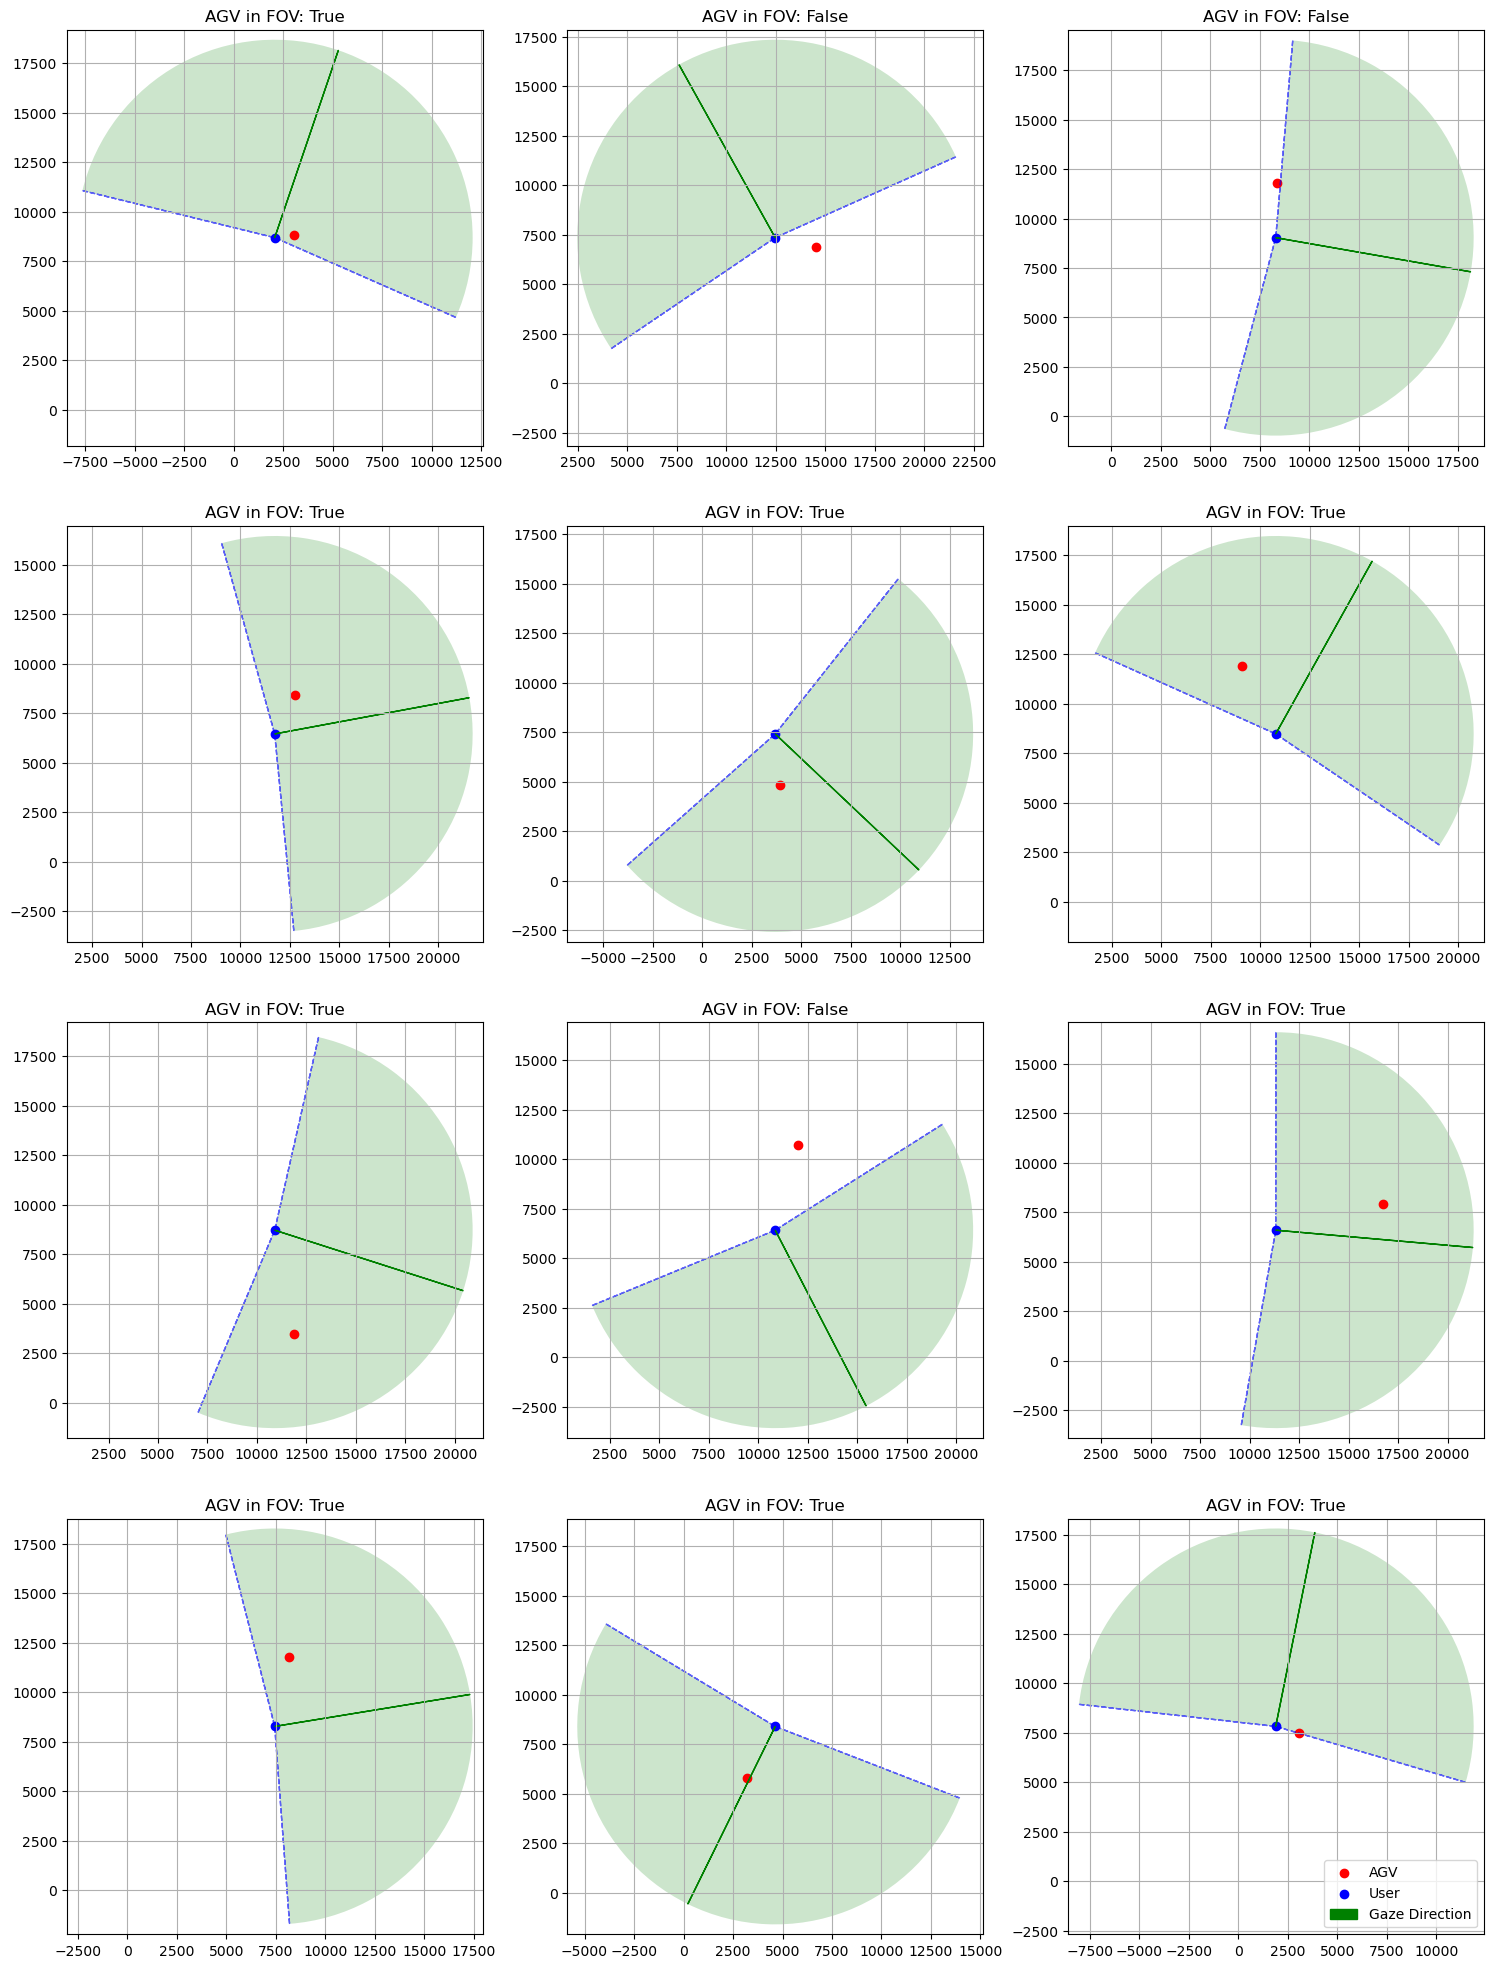

In [278]:
from matplotlib.patches import Wedge

# Pick 24 random entries
sample_data = study_data_by_sec.sample(12, random_state=42).reset_index()

# Set up subplots
fig, axes = plt.subplots(4, 3, figsize=(15, 20))  # 4 rows x 6 columns
axes = axes.flatten()

# Loop through each random entry
for idx, row in sample_data.iterrows():
    
    ax = axes[idx]
    
    # User position
    user_pos = np.array([row['User_X'], row['User_Y']])
    
    # AGV position
    agv_pos = np.array([row['AGV_X'], row['AGV_Y']])
    
    # Gaze direction (project onto XY-plane)
    gaze_dir = np.array([row['GazeDirection_X'], row['GazeDirection_Y']])
    
    # Normalize gaze direction for consistent arrow length
    gaze_dir_norm = gaze_dir / (np.linalg.norm(gaze_dir) + 1e-6)
    
    # Length of arrows for plotting
    arrow_len = 10000.0
    gaze_arrow = gaze_dir_norm * arrow_len
    
    # Compute FOV boundary angles (+/- 95 degrees)
    angle_rad = np.arctan2(gaze_dir_norm[1], gaze_dir_norm[0])  # In radians
    
    left_bound_angle_rad = angle_rad + np.radians(95)
    right_bound_angle_rad = angle_rad - np.radians(95)
    
    # Convert to degrees for Wedge
    angle_deg = np.degrees(angle_rad)
    left_bound_angle_deg = angle_deg + 95
    right_bound_angle_deg = angle_deg - 95
    
    # Create FOV wedge (matplotlib uses degrees and counterclockwise)
    fov_wedge = Wedge(
        center=(user_pos[0], user_pos[1]),
        r=arrow_len,
        theta1=right_bound_angle_deg,
        theta2=left_bound_angle_deg,
        facecolor='green',
        alpha=0.2  # Transparency for FOV
    )
    ax.add_patch(fov_wedge)
    
    # Compute vectors for boundaries
    left_bound_vec = np.array([np.cos(left_bound_angle_rad), np.sin(left_bound_angle_rad)]) * arrow_len
    right_bound_vec = np.array([np.cos(right_bound_angle_rad), np.sin(right_bound_angle_rad)]) * arrow_len
    
    # Plot AGV position
    ax.scatter(agv_pos[0], agv_pos[1], color='red', label='AGV')
    
    # Plot user position
    ax.scatter(user_pos[0], user_pos[1], color='blue', label='User')
    
    # Plot gaze direction arrow
    ax.arrow(user_pos[0], user_pos[1], gaze_arrow[0], gaze_arrow[1], 
             head_width=0.3, head_length=0.3, fc='green', ec='green', label='Gaze Direction')
    
    # Plot FOV boundary dashed arrows
    ax.arrow(user_pos[0], user_pos[1], left_bound_vec[0], left_bound_vec[1], 
             linestyle='dashed', color='blue', alpha=0.6)
    
    ax.arrow(user_pos[0], user_pos[1], right_bound_vec[0], right_bound_vec[1], 
             linestyle='dashed', color='blue', alpha=0.6)
    
    # Set title with AGV_in_FOV info
    title = f"AGV in FOV: {row['AGV_in_FOV']}"
    ax.set_title(title)
    
    # Set axis limits to keep plots consistent
    ax.set_xlim(user_pos[0] - 10500, user_pos[0] + 10500)
    ax.set_ylim(user_pos[1] - 10500, user_pos[1] + 10500)
    
    ax.set_aspect('equal')
    
    # Show grid and axes
    ax.grid(True)
    ax.axis('on')  # Turns axes back on

# Add a legend to the last plot
axes[-1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [279]:
study_data_by_sec['AGV_in_FOV_shift'] = study_data_by_sec.groupby('PID')['AGV_in_FOV'].shift()
transitions = study_data_by_sec[study_data_by_sec['AGV_in_FOV'] != study_data_by_sec['AGV_in_FOV_shift']]
print(f"Number of FOV transitions: {len(transitions)}")

Number of FOV transitions: 84074


In [280]:
study_data_by_sec.groupby('AGV_in_FOV')['User_Relative_Speed'].describe()

,count,mean,std,min,25%,50%,75%,max
AGV_in_FOV,,,,,,,,
False,2634144.0,601.144790,4444.978505,0.0,0.0,6.213550,135.440816,62093.070300
True,4742169.0,408.685995,3637.169093,0.0,0.0,7.403191,128.507679,61946.534975


In [281]:
result = ttest_ind(
    study_data_by_sec[study_data_by_sec['AGV_in_FOV']]['AGV_User_distance'],
    study_data_by_sec[~study_data_by_sec['AGV_in_FOV']]['AGV_User_distance']
)

# Extract and format the p-value and t-statistic to 3 significant figures
formatted_t = f"{result.statistic:.5g}"
formatted_p = f"{result.pvalue:.10g}"

print(f"T-statistic: {formatted_t}")
print(f"P-value: {formatted_p}")

T-statistic: -635.76
P-value: 0


In [282]:
study_data_by_sec.groupby('AGV_in_FOV')['AGV_User_distance'].describe()

,count,mean,std,min,25%,50%,75%,max
AGV_in_FOV,,,,,,,,
False,2634144.0,5347.688997,3478.582912,227.151124,2502.342135,4960.790918,8050.960703,12727.458335
True,4742169.0,3832.915497,2869.199916,132.635928,1672.797318,3332.523108,4915.635123,12653.098907


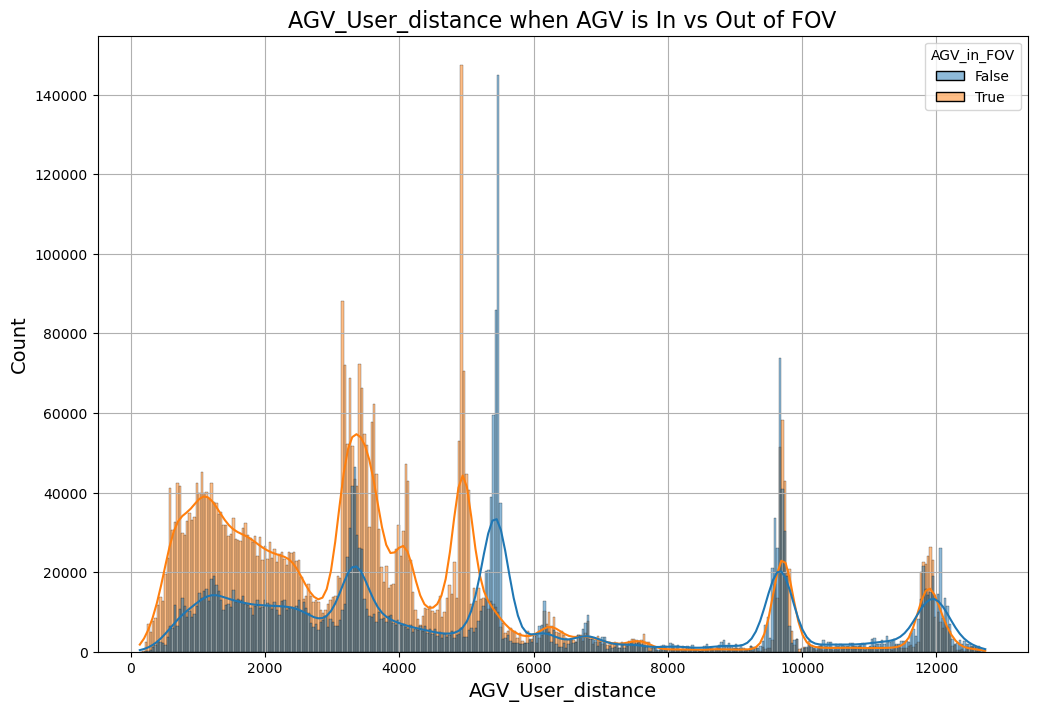

In [283]:
plt.figure(figsize=(12, 8)) 

sns.histplot(
    data=study_data_by_sec,
    x='AGV_User_distance',
    hue='AGV_in_FOV',
    kde=True
)

plt.title("AGV_User_distance when AGV is In vs Out of FOV", fontsize=16)
plt.xlabel("AGV_User_distance", fontsize=14)
plt.ylabel("Count", fontsize=14)

plt.grid(True)

plt.show()

In [284]:
grouped_fov = study_data_by_sec.groupby(['PID', 'DRate', 'AGVname'])['AGV_in_FOV'].mean().reset_index()

# Rename column to clarify meaning
grouped_fov.rename(columns={'AGV_in_FOV': 'FOV_Percentage'}, inplace=True)

# Preview the result
grouped_fov.head()

,PID,DRate,AGVname,FOV_Percentage
0,1,High,1,0.344828
1,1,High,2,0.487805
2,1,High,3,0.655172
3,1,High,4,0.730769
4,1,High,5,0.984375


In [285]:
data['FOV_Percentage'] = None  # This triggers the suffixing

data = data.merge(
    grouped_fov[['PID', 'DRate', 'AGVname', 'FOV_Percentage']],
    on=['PID', 'DRate', 'AGVname'],
    how='left',
    suffixes=('', '_new')
)

# Now it makes sense to do:
data['FOV_Percentage'] = data['FOV_Percentage_new']
data.drop(columns=['FOV_Percentage_new'], inplace=True)

In [286]:
data.head()

,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,Trust_before,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Duration,FOV_Percentage
0,1,High,2024-5-3,14,28,53,1,1900-01-01 15:02:48,1900-01-01 15:03:38,219,...,4.9,74.580213,100.420508,730.13,1188.92,1532.83,1771.61,N\A,50.0,0.344828
1,1,High,2024-5-3,14,28,53,2,1900-01-01 15:03:47,1900-01-01 15:04:29,0,...,10.0,47.888087,232.345812,14.56,97.05,108.21,247.34,N\A,42.0,0.487805
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,10.0,63.130599,120.176130,282.09,482.54,821.32,1067.08,User,57.0,0.655172
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,10.0,43.571998,263.284416,421.34,544.15,577.55,610.84,User,51.0,0.730769
4,1,High,2024-5-3,14,28,53,5,1900-01-01 15:06:41,1900-01-01 15:07:44,868,...,7.0,93.720008,91.614207,486.65,852.85,1225.51,1722.14,N\A,63.0,0.984375


In [287]:
print(data.columns.tolist())

['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime', 'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist', 'std_dist', 'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd', 'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender', 'Ethnicity', 'GamingFrequency', 'VRExperience', 'VRHeadsetExperience', 'AGVInteraction', 'PerfectAutomation', 'TrustPropensity', 'AutomationExperience', 'Trust1', 'Trust2', 'MWL', 'Assessment', 'Gaze_on_AGV', 'User_Trajectory', 'AGV_Approaching', 'AGV_User_Combination', 'AGV_Path_Complexity', 'Trust_before', 'User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_3', 'Frechet_Distance_5', 'Frechet_Distance_7', 'Frechet_Distance_10', 'Cross_First', 'Duration', 'FOV_Percentage']


In [288]:
null_counts = data.isnull().sum()
null_counts

PID                      0
DRate                    0
date                     0
hr                       0
min                      0
s                        0
AGVname                  0
StartTime                0
EndTime                  0
GazeDuration             0
mean_dist                0
min_dist                 0
max_dist                 0
std_dist                 0
mean_agv_spd             0
min_agv_spd              0
max_agv_spd              0
std_spd                  0
task                     0
Trust                    0
Safe                     0
Comfort                  0
Expect                   0
Age                      0
Gender                   0
Ethnicity                0
GamingFrequency          0
VRExperience             0
VRHeadsetExperience      0
AGVInteraction           0
PerfectAutomation        0
TrustPropensity          0
AutomationExperience     0
Trust1                   0
Trust2                   0
MWL                      0
Assessment               0
G

In [289]:
# Create a grouping based on median FOV_Percentage
median_fov = data['FOV_Percentage'].median()
print(median_fov)

data['High_FOV'] = data['FOV_Percentage'] > median_fov

# Merge back subjective measures (Trust, etc.) at the same group level if they exist
# Assuming you already have a grouped dataset with Trust, Safe, Comfort, Expect

# Perform t-tests for each subjective variable
columns_to_test = ['Trust', 'Safe', 'Comfort', 'Expect']

for col in columns_to_test:
    result = ttest_ind(
        data[data['High_FOV']][col].dropna(),
        data[~data['High_FOV']][col].dropna()
    )
    
    formatted_t = f"{result.statistic:.3g}"
    formatted_p = f"{result.pvalue:.3g}"
    
    print(f"Column: {col}")
    print(f"  T-statistic: {formatted_t}")
    print(f"  P-value:     {formatted_p}")
    print("-" * 40)

0.5714285714285714
Column: Trust
  T-statistic: -2.33
  P-value:     0.0202
----------------------------------------
Column: Safe
  T-statistic: -1.66
  P-value:     0.0971
----------------------------------------
Column: Comfort
  T-statistic: -1.83
  P-value:     0.067
----------------------------------------
Column: Expect
  T-statistic: -0.875
  P-value:     0.382
----------------------------------------


In [290]:
cross_first_data = data[data['Cross_First'].isin(['AGV', 'User'])]
# cross_first_data = cross_first_data.drop(['Cross_First_Flag', 'Trust_before'], axis=1)
cross_first_data['Cross_First'] = np.where(cross_first_data['Cross_First'] == 'User', 0, 1)
# cross_first_data = cross_first_data.dropna(subset=['Trust_before'])
cross_first_data.head()

C:\Users\HIALAB\AppData\Local\Temp\ipykernel_108356\4226173574.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cross_first_data['Cross_First'] = np.where(cross_first_data['Cross_First'] == 'User', 0, 1)


,PID,DRate,date,hr,min,s,AGVname,StartTime,EndTime,GazeDuration,...,User_Relative_Speed,AGV_Relative_Speed,Frechet_Distance_3,Frechet_Distance_5,Frechet_Distance_7,Frechet_Distance_10,Cross_First,Duration,FOV_Percentage,High_FOV
2,1,High,2024-5-3,14,28,53,3,1900-01-01 15:04:37,1900-01-01 15:05:34,268,...,63.130599,120.176130,282.09,482.54,821.32,1067.08,0,57.0,0.655172,True
3,1,High,2024-5-3,14,28,53,4,1900-01-01 15:05:46,1900-01-01 15:06:37,779,...,43.571998,263.284416,421.34,544.15,577.55,610.84,0,51.0,0.730769,True
6,1,High,2024-5-3,14,28,53,7,1900-01-01 15:09:07,1900-01-01 15:09:50,537,...,62.064945,228.573947,379.71,540.52,665.30,941.60,0,43.0,0.431818,False
7,1,High,2024-5-3,14,28,53,8,1900-01-01 15:10:07,1900-01-01 15:11:08,650,...,59.394993,161.124764,331.78,693.33,1038.91,1483.72,0,61.0,0.774194,True
8,1,High,2024-5-3,14,28,53,9,1900-01-01 15:11:12,1900-01-01 15:12:13,856,...,59.041137,161.124877,115.79,379.19,541.15,1029.62,1,61.0,0.370968,False


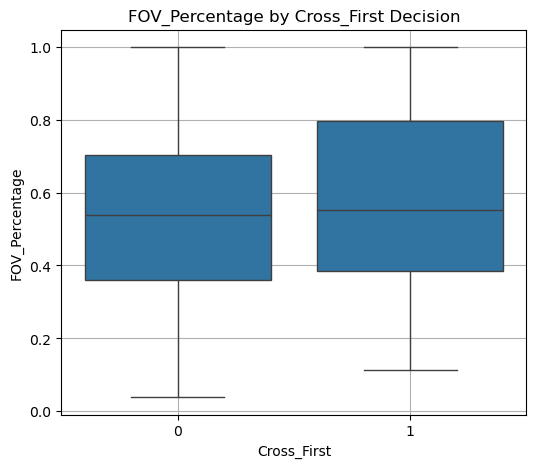

In [291]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Cross_First', y='FOV_Percentage', data=cross_first_data)
plt.title('FOV_Percentage by Cross_First Decision')
plt.xlabel('Cross_First')
plt.ylabel('FOV_Percentage')
plt.grid(True)
plt.show()

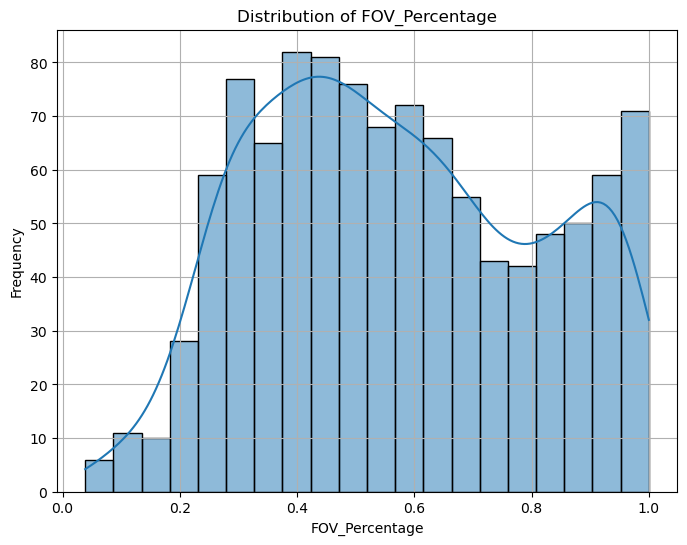

In [292]:
plt.figure(figsize=(8, 6))
sns.histplot(cross_first_data['FOV_Percentage'], kde=True, bins=20)
plt.title('Distribution of FOV_Percentage')
plt.xlabel('FOV_Percentage')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [293]:
group_0 = cross_first_data[cross_first_data['Cross_First'] == 0]['FOV_Percentage']
group_1 = cross_first_data[cross_first_data['Cross_First'] == 1]['FOV_Percentage']

# Perform Mann-Whitney U test
u_stat, p_value = mannwhitneyu(group_0, group_1, alternative='two-sided')

# Display results
print(f"Mann-Whitney U statistic: {u_stat:.3f}")
print(f"P-value: {p_value:.3g}")

Mann-Whitney U statistic: 118891.000
P-value: 0.0673


In [294]:
corr, pval = pointbiserialr(cross_first_data['Cross_First'], cross_first_data['FOV_Percentage'])

print(f"Point-Biserial Correlation: {corr:.3g}, P-value: {pval:.3g}")

Point-Biserial Correlation: 0.0713, P-value: 0.0197


In [295]:
X = cross_first_data[['FOV_Percentage']]
X = sm.add_constant(X)
y = cross_first_data['Cross_First']

model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.636310
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            Cross_First   No. Observations:                 1069
Model:                          Logit   Df Residuals:                     1067
Method:                           MLE   Df Model:                            1
Date:                Mon, 10 Mar 2025   Pseudo R-squ.:                0.004000
Time:                        15:53:44   Log-Likelihood:                -680.22
converged:                       True   LL-Null:                       -682.95
Covariance Type:            nonrobust   LLR p-value:                   0.01942
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.3147      0.167      1.879      0.060      -0.013       0.643
FOV_Percentage   

In [340]:
# Copy your data
df = data.copy()

# Define features and target
# Drop columns that are not features
cols_to_drop = ['PID', 'DRate', 'date', 'hr', 'min', 's', 'AGVname', 'StartTime', 'EndTime', 'GazeDuration', 'mean_dist', 'min_dist', 'max_dist', 'std_dist',
                'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'std_spd', 'task', 'Trust', 'Safe', 'Comfort', 'Expect', 'Age', 'Gender', 'Ethnicity',
                'GamingFrequency', 'VRExperience', 'VRHeadsetExperience', 'AGVInteraction', 'PerfectAutomation', 'TrustPropensity', 'AutomationExperience',
                'Trust1', 'Trust2', 'MWL', 'Assessment', 'Gaze_on_AGV', 'User_Trajectory', 'AGV_Approaching', 'AGV_User_Combination', 'AGV_Path_Complexity', 'Trust_before',
                'User_Relative_Speed', 'AGV_Relative_Speed', 'Frechet_Distance_3', 'Frechet_Distance_5', 'Frechet_Distance_7', 'Frechet_Distance_10', 'Cross_First',
                'FOV_Percentage', 'High_FOV'
]

selected_columns_df = ['User_Trajectory', 'AGV_Approaching', 'AGV_User_Combination', 'DRate', 'Duration',
       'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'mean_agv_spd', 'min_agv_spd', 'max_agv_spd', 'Cross_First', 'User_Relative_Speed',
       'Frechet_Distance_10']

numerical_columns = ['Duration',
       'GazeDuration', 'mean_dist', 'min_dist', 'max_dist',
       'mean_agv_spd', 'min_agv_spd', 'max_agv_spd','User_Relative_Speed',
       'Frechet_Distance_10']

categorical_columns = ['User_Trajectory', 'AGV_Approaching', 'AGV_User_Combination', 'DRate', 'Cross_First']

X = data[selected_columns_df]
X[1000:1100]

,User_Trajectory,AGV_Approaching,AGV_User_Combination,DRate,Duration,GazeDuration,mean_dist,min_dist,max_dist,mean_agv_spd,min_agv_spd,max_agv_spd,Cross_First,User_Relative_Speed,Frechet_Distance_10
1000,Straight,West,West - Straight,Low,66.0,613,3995.98,1129.21,5501.80,3.34,-4.05,15.22,AGV,45.097754,903.54
1001,Diagonal,East,East - Diagonal,Low,60.0,716,3893.75,497.68,6218.82,3.18,-5.43,15.30,AGV,62.273984,938.32
1002,Straight,Southeast,Southeast - Straight,Low,80.0,652,2714.36,721.72,4154.92,2.62,-2.87,10.08,User,76.568588,1178.82
1003,Straight,Southwest,Southwest - Straight,Low,45.0,16,4961.35,721.27,11834.89,8.33,-2.33,15.22,AGV,50.190877,1027.77
1004,Diagonal,Southeast,Southeast - Diagonal,Low,56.0,900,2490.09,621.77,4690.53,3.84,-4.23,15.21,User,65.780225,943.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,Straight,West,West - Straight,Low,54.0,342,3900.97,998.23,5543.61,4.06,-4.49,15.21,AGV,54.562211,1124.62
1096,Diagonal,East,East - Diagonal,Low,57.0,771,3662.61,579.63,6098.82,3.34,-5.41,15.22,AGV,63.771392,1012.91
1097,Straight,Southeast,Southeast - Straight,Low,78.0,642,2764.48,781.76,4100.57,2.70,-2.93,10.73,User,77.651618,1164.93
1098,Straight,Southwest,Southwest - Straight,Low,48.0,777,3931.32,562.27,11824.61,7.72,-3.37,15.22,AGV,45.100470,915.94


In [342]:
# Apply one-hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(X[categorical_columns])

# Add encoded columns back to the DataFrame
encoded_columns = encoder.get_feature_names_out(categorical_columns)
encoded_df = pd.DataFrame(encoded_data, columns=encoded_columns, index=X.index)
encoded_X = pd.concat([X.drop(columns=categorical_columns), encoded_df], axis=1)
encoded_X[1000:1200]

,Duration,GazeDuration,mean_dist,min_dist,max_dist,mean_agv_spd,min_agv_spd,max_agv_spd,User_Relative_Speed,Frechet_Distance_10,...,AGV_User_Combination_Southwest - Straight,AGV_User_Combination_West - Diagonal,AGV_User_Combination_West - Straight,DRate_High,DRate_Low,Cross_First_AGV,Cross_First_N\A,Cross_First_Null,Cross_First_User,Cross_First_nan
1000,66.0,613,3995.98,1129.21,5501.80,3.34,-4.05,15.22,45.097754,903.54,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1001,60.0,716,3893.75,497.68,6218.82,3.18,-5.43,15.30,62.273984,938.32,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1002,80.0,652,2714.36,721.72,4154.92,2.62,-2.87,10.08,76.568588,1178.82,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1003,45.0,16,4961.35,721.27,11834.89,8.33,-2.33,15.22,50.190877,1027.77,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1004,56.0,900,2490.09,621.77,4690.53,3.84,-4.23,15.21,65.780225,943.17,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,43.0,278,2903.23,1014.87,5633.38,4.42,-0.04,15.23,84.632453,171.26,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1196,100.0,369,7848.44,498.43,11801.10,4.70,-3.51,15.23,38.850771,660.11,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1197,62.0,0,2407.54,960.47,4517.78,3.56,-3.63,15.21,37.828845,783.93,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1198,76.0,530,3977.00,815.04,5891.59,2.47,-5.57,15.21,47.394987,523.78,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [234]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8867924528301887
Confusion Matrix:
 [[119  14]
 [ 16 116]]
Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.89      0.89       133
        True       0.89      0.88      0.89       132

    accuracy                           0.89       265
   macro avg       0.89      0.89      0.89       265
weighted avg       0.89      0.89      0.89       265



In [242]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

# Get coefficients and intercept
coefs = log_reg.coef_[0]
intercept = log_reg.intercept_[0]

# Combine into a DataFrame for readability
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefs
})

# Sort by absolute value to see most impactful features
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
coef_df.sort_values(by='abs_coef', ascending=False, inplace=True)

# Show top coefficients
print(coef_df[['Feature', 'Coefficient']].head(10))

Accuracy: 0.751
                Feature  Coefficient
1             mean_dist    -1.983672
3              max_dist     1.880103
10   AGV_Relative_Speed    -0.894501
0          GazeDuration     0.661379
5          mean_agv_spd    -0.445288
11   Frechet_Distance_3    -0.416996
2              min_dist     0.223268
9   User_Relative_Speed     0.117459
4              std_dist    -0.116437
6           min_agv_spd     0.073299


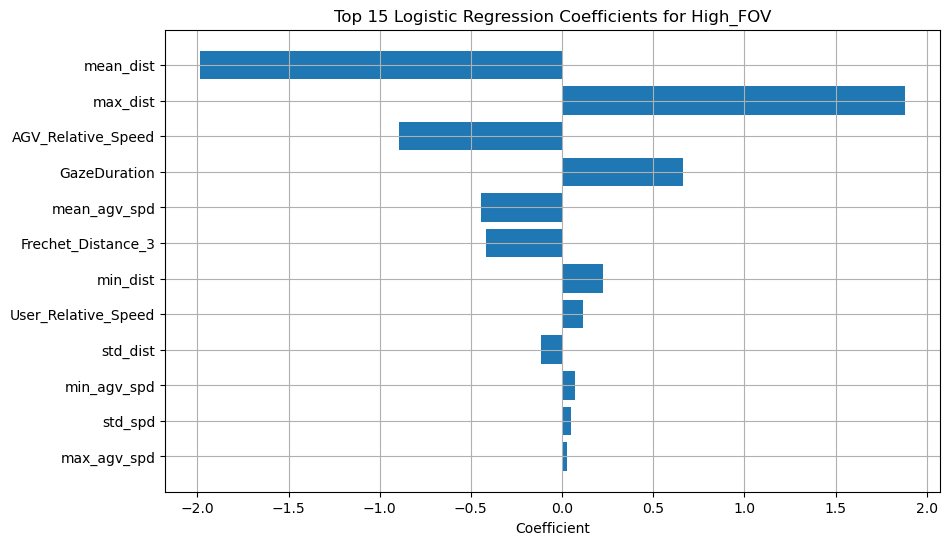

In [238]:
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'][:15][::-1], coef_df['Coefficient'][:15][::-1])
plt.xlabel("Coefficient")
plt.title("Top 15 Logistic Regression Coefficients for High_FOV")
plt.grid(True)
plt.show()